# Exploración de Datos

### Carga de las librerías necesarias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Carga del Dataset

In [3]:
# Ruta PC Josué
df = pd.read_csv(r'C:\Users\XPC\Documents\CUC\Cuatri 5\BD - 143 - Programación ll\Trabajos\Proyecto 3\data\processed\turismo_combinado_2025_2026.csv')

# Ruta Mau

### Uso del Comando HEAD para hacer una revisión superficial de los datos


In [9]:
df.head()

,Zona_Pais,01-2025,02-2025,03-2025,04-2025,05-2025,06-2025,07-2025,08-2025,09-2025,10-2025,11-2025,12-2025,01-2026,02-2026,Total_2025,Total_2026,Total
0,TOTAL,298475.0,293784.0,336476.0,252867.0,205803.0,232571.0,262048.0,199959.0,121815.0,145663.0,247387.0,347143.0,298475.0,293784.0,2943991.0,2943991.0,5887982.0
1,AMERICA DEL NORTE,202581.0,199882.0,247595.0,171151.0,149633.0,177467.0,179300.0,124758.0,69698.0,85817.0,157377.0,234341.0,202581.0,199882.0,1999600.0,1999600.0,3999200.0
2,CANADA,42440.0,39843.0,38851.0,23193.0,11508.0,8996.0,12551.0,10399.0,5144.0,9703.0,28897.0,42556.0,42440.0,39843.0,274081.0,274081.0,548162.0
3,ESTADOS UNIDOS,154170.0,153380.0,200831.0,138949.0,130004.0,161583.0,156348.0,104920.0,57064.0,69581.0,119833.0,181144.0,154170.0,153380.0,1627807.0,1627807.0,3255614.0
4,MEXICO,5971.0,6659.0,7913.0,9009.0,8121.0,6888.0,10401.0,9439.0,7490.0,6533.0,8647.0,10641.0,5971.0,6659.0,97712.0,97712.0,195424.0


### Inspección General

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Zona_Pais   83 non-null     str    
 1   01-2025     83 non-null     float64
 2   02-2025     83 non-null     float64
 3   03-2025     83 non-null     float64
 4   04-2025     83 non-null     float64
 5   05-2025     83 non-null     float64
 6   06-2025     83 non-null     float64
 7   07-2025     83 non-null     float64
 8   08-2025     83 non-null     float64
 9   09-2025     83 non-null     float64
 10  10-2025     83 non-null     float64
 11  11-2025     83 non-null     float64
 12  12-2025     83 non-null     float64
 13  01-2026     83 non-null     float64
 14  02-2026     83 non-null     float64
 15  Total_2025  83 non-null     float64
 16  Total_2026  83 non-null     float64
 17  Total       83 non-null     float64
dtypes: float64(17), str(1)
memory usage: 11.8 KB


### Resumen Estadístico

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
01-2025,83.0,10788.253012,42791.446291,0.0,79.5,438.0,2224.0,298475.0
02-2025,83.0,10618.698795,42231.506746,0.0,85.0,462.0,2329.0,293784.0
03-2025,83.0,12161.783133,50320.789180,0.0,106.5,500.0,2230.5,336476.0
04-2025,83.0,9139.771084,36471.791873,0.0,87.0,383.0,2300.0,252867.0
05-2025,83.0,7438.662651,30902.742067,0.0,99.5,332.0,1567.5,205803.0
06-2025,83.0,8406.180723,36122.857767,0.0,78.0,279.0,1643.5,232571.0
07-2025,83.0,9471.614458,38419.059190,0.0,87.0,382.0,2421.0,262048.0
08-2025,83.0,7227.433735,28121.920461,0.0,80.5,356.0,2031.5,199959.0
09-2025,83.0,4402.951807,16531.703645,0.0,64.5,232.0,1554.5,121815.0
10-2025,83.0,5264.939759,19930.734345,0.0,73.0,274.0,1570.5,145663.0


### Visualización de Valores Nulos

In [12]:
df.isna().mean().sort_values(ascending=False)

Zona_Pais     0.0
01-2025       0.0
02-2025       0.0
03-2025       0.0
04-2025       0.0
05-2025       0.0
06-2025       0.0
07-2025       0.0
08-2025       0.0
09-2025       0.0
10-2025       0.0
11-2025       0.0
12-2025       0.0
01-2026       0.0
02-2026       0.0
Total_2025    0.0
Total_2026    0.0
Total         0.0
dtype: float64

### Procesamiento previo de los datos para la realización de gráficos

In [4]:
# Definimos las columnas de los meses para facilitar el acceso
meses_2025 = [col for col in df.columns if '-2025' in col and 'Total' not in col]
meses_2026 = [col for col in df.columns if '-2026' in col and 'Total' not in col]
todos_los_meses = meses_2025 + meses_2026

# Separamos la fila global para análisis de tendencia
df_global = df[df['Zona_Pais'] == 'TOTAL']

# Creamos un filtro para las regiones principales (puedes ajustar esta lista)
regiones = ['AMERICA DEL NORTE', 'CENTROAMERICA', 'AMERICA DEL SUR', 'EUROPA', 'CARIBE', 'ASIA', 'AFRICA']
df_regiones = df[df['Zona_Pais'].isin(regiones)]

# Y otro para ver solo países (excluyendo totales y regiones)
exclusiones = ['TOTAL', 'OTROS ASIA Y EL PACIFICO'] + regiones
df_paises = df[~df['Zona_Pais'].isin(exclusiones)]

### Flujo de Turistas

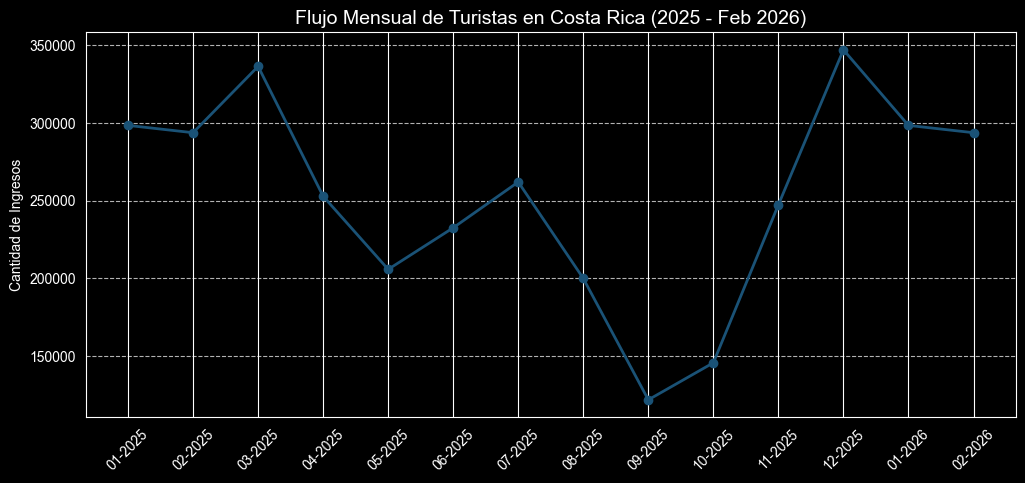

In [5]:
plt.figure(figsize=(12, 5))
valores_mensuales = df_global[todos_los_meses].values.flatten()

plt.plot(todos_los_meses, valores_mensuales, marker='o', color='#1A5276', linewidth=2)
plt.title('Flujo Mensual de Turistas en Costa Rica (2025 - Feb 2026)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylabel('Cantidad de Ingresos')
plt.show()

### Región que más turistas aporta en 2025

C:\Users\XPC\AppData\Local\Temp\ipykernel_26932\931361449.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_regiones_sorted, x='Total_2025', y='Zona_Pais', palette='viridis')


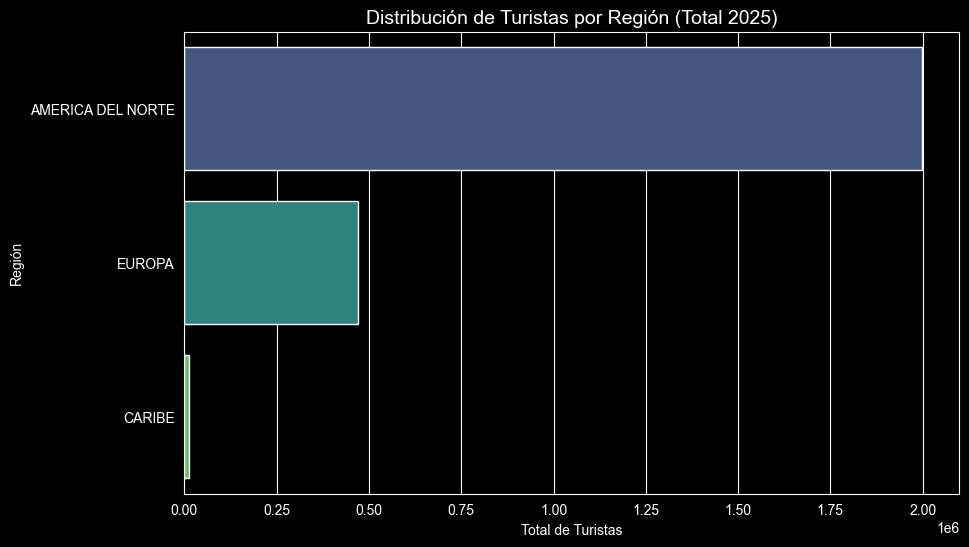

In [7]:
plt.figure(figsize=(10, 6))

df_regiones_sorted = df_regiones.sort_values('Total_2025', ascending=False)

sns.barplot(data=df_regiones_sorted, x='Total_2025', y='Zona_Pais', palette='viridis')
plt.title('Distribución de Turistas por Región (Total 2025)', fontsize=14)
plt.xlabel('Total de Turistas')
plt.ylabel('Región')
plt.show()

### Países/Regiones que más turistas aportan en 2025

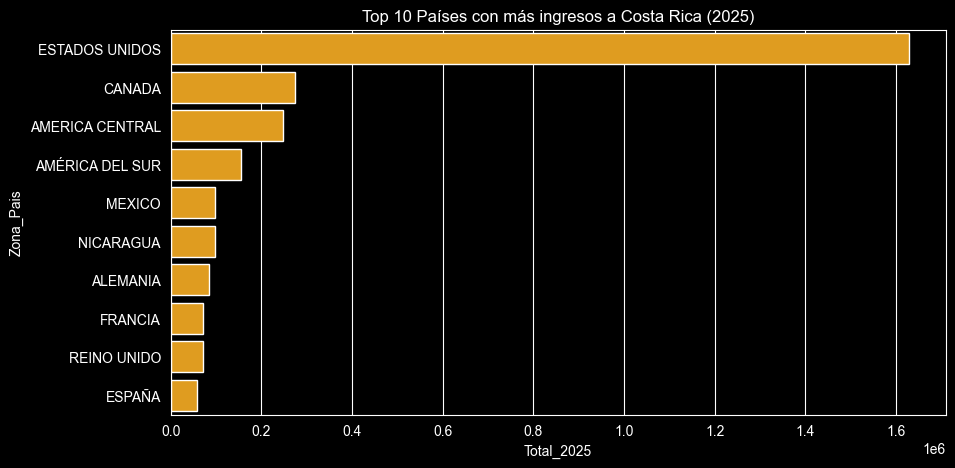

In [8]:
top_10_paises = df_paises.sort_values('Total_2025', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_paises, x='Total_2025', y='Zona_Pais', color='orange')
plt.title('Top 10 Países con más ingresos a Costa Rica (2025)')
plt.show()